In [ ]:
import pandas as pd
import math

class CAMformerChip:
    def __init__(self, num_cores):
        # Base parameters for a single core (m=1, n=1024, k=1024, dv=1024)
        self.base_latency = 0.001  # seconds
        self.base_power = 0.0001   # Watts
        self.base_area = 1.1       # mm2
        self.num_cores = num_cores

        # Calculate total chip metrics
        self.total_area = self.base_area * num_cores
        self.total_power = self.base_power * num_cores

        # Performance tracking
        self.total_latency = 0
        self.current_model = None
        self.model_results = {}

    def process_layer(self, m, n, k, dv):
        """
        Process a single layer with the given dimensions.
        Assumes work can be parallelized across cores for the m dimension.
        """
        # Calculate how many parallel operations we can do
        ops_per_core = math.ceil(m / self.num_cores)

        # Calculate actual latency for this layer
        # If m is smaller than number of cores, we still use the full base_latency
        effective_latency = self.base_latency * max(1, ops_per_core)

        self.total_latency += effective_latency
        return effective_latency

    def start_new_model(self, model_name):
        """Start processing a new model"""
        if self.current_model:
            self.finish_model()

        self.current_model = model_name
        self.total_latency = 0

    def finish_model(self):
        """Save results for the current model"""
        if self.current_model:
            self.model_results[self.current_model] = {
                'latency': self.total_latency,
                'power': self.total_power,
                'area': self.total_area
            }

    def print_results(self):
        """Print results for all processed models"""
        print(f"\nChip Configuration:")
        print(f"Number of cores: {self.num_cores}")
        print(f"Total area: {self.total_area:.2f} mm²")
        print(f"Total power: {self.total_power:.6f} W")
        print("\nModel Results:")

        for model, results in self.model_results.items():
            print(f"\n{model}:")
            print(f"  Total latency: {results['latency']:.6f} seconds")
            print(f"  Power consumption: {results['power']:.6f} W")
            print(f"  Area: {results['area']:.2f} mm²")

def process_models(csv_path, num_cores):
    """Process all models in the CSV file with given number of cores"""
    # Initialize chip
    chip = CAMformerChip(num_cores)

    # Read CSV file
    df = pd.read_csv(csv_path)

    # Process each model
    current_model = None

    for _, row in df.iterrows():
        if current_model != row['model']:
            current_model = row['model']
            chip.start_new_model(current_model)

        # Process layer
        latency = chip.process_layer(
            m=row['m'],
            n=row['n'],
            k=row['k'],
            dv=row['dv']
        )

    # Finish last model
    chip.finish_model()

    # Print results
    chip.print_results()

    return chip

# Example usage
if __name__ == "__main__":
    # Process models with 8 cores
    chip = process_models('/content/model_data.csv', num_cores=8)

    # You can also try different numbers of cores
    # chip = process_models('/content/model_data.csv', num_cores=16)
    # chip = process_models('/content/model_data.csv', num_cores=32)


Chip Configuration:
Number of cores: 8
Total area: 8.80 mm²
Total power: 0.000800 W

Model Results:

bert-base-squad-v2:
  Total latency: 0.768000 seconds
  Power consumption: 0.000800 W
  Area: 8.80 mm²

bert-large-squad-v2:
  Total latency: 1.536000 seconds
  Power consumption: 0.000800 W
  Area: 8.80 mm²

bert-base-cola:
  Total latency: 0.768000 seconds
  Power consumption: 0.000800 W
  Area: 8.80 mm²

bert-base-mnli-mm:
  Total latency: 0.768000 seconds
  Power consumption: 0.000800 W
  Area: 8.80 mm²

bert-base-mnli-m:
  Total latency: 0.768000 seconds
  Power consumption: 0.000800 W
  Area: 8.80 mm²

bert-base-mrpc:
  Total latency: 0.768000 seconds
  Power consumption: 0.000800 W
  Area: 8.80 mm²

bert-base-qnli:
  Total latency: 0.768000 seconds
  Power consumption: 0.000800 W
  Area: 8.80 mm²

bert-base-qqp:
  Total latency: 0.768000 seconds
  Power consumption: 0.000800 W
  Area: 8.80 mm²

bert-base-rte:
  Total latency: 0.768000 seconds
  Power consumption: 0.000800 W
  Ar

In [ ]:
import pandas as pd
import math

class CAMformerChip:
    def __init__(self, num_cores):
        # Base parameters for a single core (m=1, n=1024, k=1024, dv=1024)
        self.base_latency = 0.001  # seconds
        self.base_power = 0.0001   # Watts
        self.base_area = 1.1       # mm2
        self.num_cores = num_cores

        # Calculate total chip metrics
        self.total_area = self.base_area * num_cores
        self.total_power = self.base_power * num_cores

        # Performance tracking
        self.total_latency = 0
        self.layer_latencies = []

    def process_layer(self, m, n, k, dv):
        """Process a single layer with the given dimensions."""
        ops_per_core = math.ceil(m / self.num_cores)
        effective_latency = self.base_latency * ops_per_core
        self.total_latency += effective_latency
        self.layer_latencies.append(effective_latency)
        return effective_latency

def process_single_model(model_name, df, cores):
    # Filter data for single model
    model_df = df[df['model'] == model_name]

    # Process model
    chip = CAMformerChip(cores)

    print(f"\nProcessing {model_name} with {cores} cores:")
    print(f"Total area: {chip.total_area:.2f} mm²")
    print(f"Total power: {chip.total_power:.6f} W")

    # Process each layer
    print("\nLayer-by-layer processing:")
    print("Layer | m, n, k, dv | Latency (s)")
    print("-" * 50)

    for _, row in model_df.iterrows():
        latency = chip.process_layer(row['m'], row['n'], row['k'], row['dv'])
        print(f"Layer {row['layer']:2d} | {row['m']}, {row['n']}, {row['k']}, {row['dv']} | {latency:.6f}")

    print("-" * 50)
    print(f"Total latency: {chip.total_latency:.6f} seconds")

    return chip

# Load data
df = pd.read_csv('/content/model_data.csv')

# Choose bert-base-squad-v2 as our example model
model_name = "bert-base-squad-v2"

# Process with 1 core
chip_1 = process_single_model(model_name, df, cores=1)

# Process with 8 cores
chip_8 = process_single_model(model_name, df, cores=8)

# Print comparison
print("\nComparison Summary:")
print("-" * 50)
print(f"Model: {model_name}")
print(f"Number of layers: {len(df[df['model'] == model_name])}")
print("\nMetric          | 1 Core     | 8 Cores    | Improvement")
print("-" * 50)
print(f"Total Latency   | {chip_1.total_latency:.6f}s | {chip_8.total_latency:.6f}s | {(chip_1.total_latency/chip_8.total_latency):.2f}x")
print(f"Area            | {chip_1.total_area:.2f}mm²  | {chip_8.total_area:.2f}mm²  | N/A")
print(f"Power          | {chip_1.total_power:.6f}W | {chip_8.total_power:.6f}W | N/A")


Processing bert-base-squad-v2 with 1 cores:
Total area: 1.10 mm²
Total power: 0.000100 W

Layer-by-layer processing:
Layer | m, n, k, dv | Latency (s)
--------------------------------------------------
Layer  1 | 512, 512, 768, 768 | 0.512000
Layer  2 | 512, 512, 768, 768 | 0.512000
Layer  3 | 512, 512, 768, 768 | 0.512000
Layer  4 | 512, 512, 768, 768 | 0.512000
Layer  5 | 512, 512, 768, 768 | 0.512000
Layer  6 | 512, 512, 768, 768 | 0.512000
Layer  7 | 512, 512, 768, 768 | 0.512000
Layer  8 | 512, 512, 768, 768 | 0.512000
Layer  9 | 512, 512, 768, 768 | 0.512000
Layer 10 | 512, 512, 768, 768 | 0.512000
Layer 11 | 512, 512, 768, 768 | 0.512000
Layer 12 | 512, 512, 768, 768 | 0.512000
--------------------------------------------------
Total latency: 6.144000 seconds

Processing bert-base-squad-v2 with 8 cores:
Total area: 8.80 mm²
Total power: 0.000800 W

Layer-by-layer processing:
Layer | m, n, k, dv | Latency (s)
--------------------------------------------------
Layer  1 | 512, 512


Summary Table:
------------------------------------------------------------
Cores | Latency (s) | Area (mm²) | Latency Improvement
------------------------------------------------------------
    1 | 0.212361 |       1.1 |               1.00x
    2 | 0.106181 |       2.2 |               2.00x
    4 | 0.053090 |       4.4 |               4.00x
    8 | 0.026545 |       8.8 |               8.00x
   16 | 0.013273 |      17.6 |              16.00x
   32 | 0.006636 |      35.2 |              32.00x


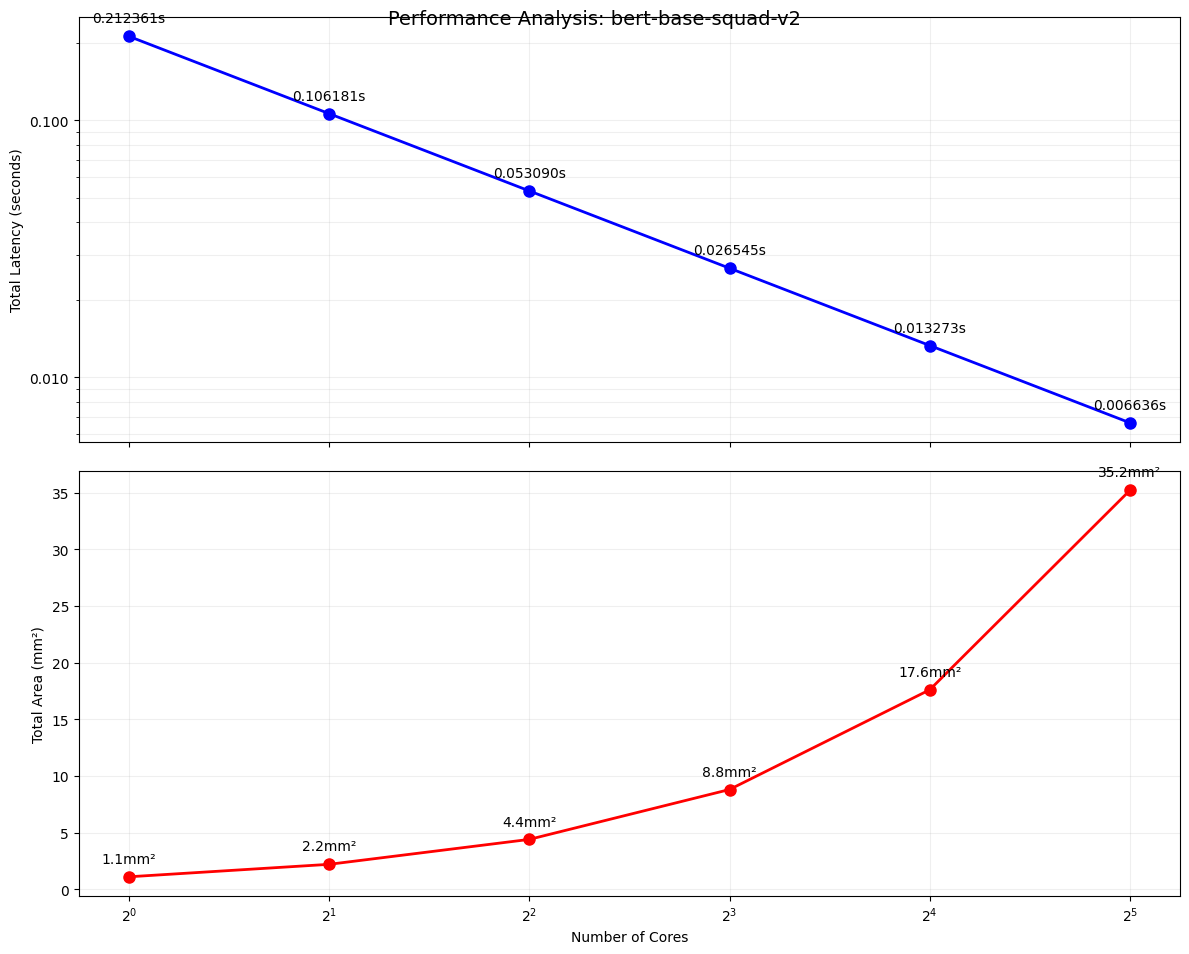

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

class CAMformerChip:
    def __init__(self, num_cores):
        self.base_latency = 3.4564e-05  # seconds
        self.base_power = 0.0001   # Watts
        self.base_area = 2.27       # mm2
        self.num_cores = num_cores
        self.total_latency = 0

    def process_layer(self, m, n, k, dv):
        ops_per_core = np.ceil(m / self.num_cores)
        effective_latency = self.base_latency * ops_per_core
        self.total_latency += effective_latency
        return effective_latency

def process_model_with_cores(model_df, num_cores):
    chip = CAMformerChip(num_cores)
    for _, row in model_df.iterrows():
        chip.process_layer(row['m'], row['n'], row['k'], row['dv'])
    return chip.total_latency

# Load data
df = pd.read_csv('/content/model_data.csv')
model_name = "bert-base-squad-v2"
model_df = df[df['model'] == model_name]

# Calculate latency for different numbers of cores
cores_range = [1, 2, 4, 8, 16, 32]
latencies = []
areas = []

for cores in cores_range:
    latency = process_model_with_cores(model_df, cores)
    area = 1.1 * cores  # base_area * num_cores
    latencies.append(latency)
    areas.append(area)

# Create figure with two subplots sharing x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fig.suptitle(f'Performance Analysis: {model_name}', fontsize=14, y=0.95)

# Plot 1: Latency vs Cores
ax1.plot(cores_range, latencies, 'b-o', linewidth=2, markersize=8)
ax1.set_ylabel('Total Latency (seconds)')
ax1.set_yscale('log')
ax1.grid(True, which="both", ls="-", alpha=0.2)
ax1.yaxis.set_major_formatter(ScalarFormatter())

# Add latency values as annotations
for i, (core, latency) in enumerate(zip(cores_range, latencies)):
    ax1.annotate(f'{latency:.6f}s',
                (core, latency),
                textcoords="offset points",
                xytext=(0,10),
                ha='center')

# Plot 2: Area vs Cores
ax2.plot(cores_range, areas, 'r-o', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Cores')
ax2.set_ylabel('Total Area (mm²)')
ax2.grid(True, which="both", ls="-", alpha=0.2)

# Add area values as annotations
for i, (core, area) in enumerate(zip(cores_range, areas)):
    ax2.annotate(f'{area:.1f}mm²',
                (core, area),
                textcoords="offset points",
                xytext=(0,10),
                ha='center')

# Set x-axis to show all core values
ax2.set_xticks(cores_range)
plt.xscale('log', base=2)

# Adjust layout to prevent overlap
plt.tight_layout()

# Print summary table
print("\nSummary Table:")
print("-" * 60)
print("Cores | Latency (s) | Area (mm²) | Latency Improvement")
print("-" * 60)
for i, cores in enumerate(cores_range):
    improvement = latencies[0] / latencies[i] if i > 0 else 1
    print(f"{cores:5d} | {latencies[i]:.6f} | {areas[i]:9.1f} | {improvement:18.2f}x")

plt.show()

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

# Path to the Arial font file
fpath = Path("/content/drive/My Drive/2. Colab Notebooks/CeNN/PDE/Arial.ttf")

# Load and register the Arial font
arial_font = fm.FontProperties(fname=fpath)
fm.fontManager.addfont(fpath) # Add the font to Matplotlib's font manager

# Set the global font to Arial
plt.rcParams['font.family'] = arial_font.get_name()

Mounted at /content/drive



Summary Table:
------------------------------------------------------------
Cores | Latency (s) | Area (mm²) | Latency Improvement
------------------------------------------------------------
    1 | 0.212361 |       1.1 |               1.00x
    2 | 0.106181 |       2.2 |               2.00x
    4 | 0.053090 |       4.4 |               4.00x
    8 | 0.026545 |       8.8 |               8.00x
   16 | 0.013273 |      17.6 |              16.00x


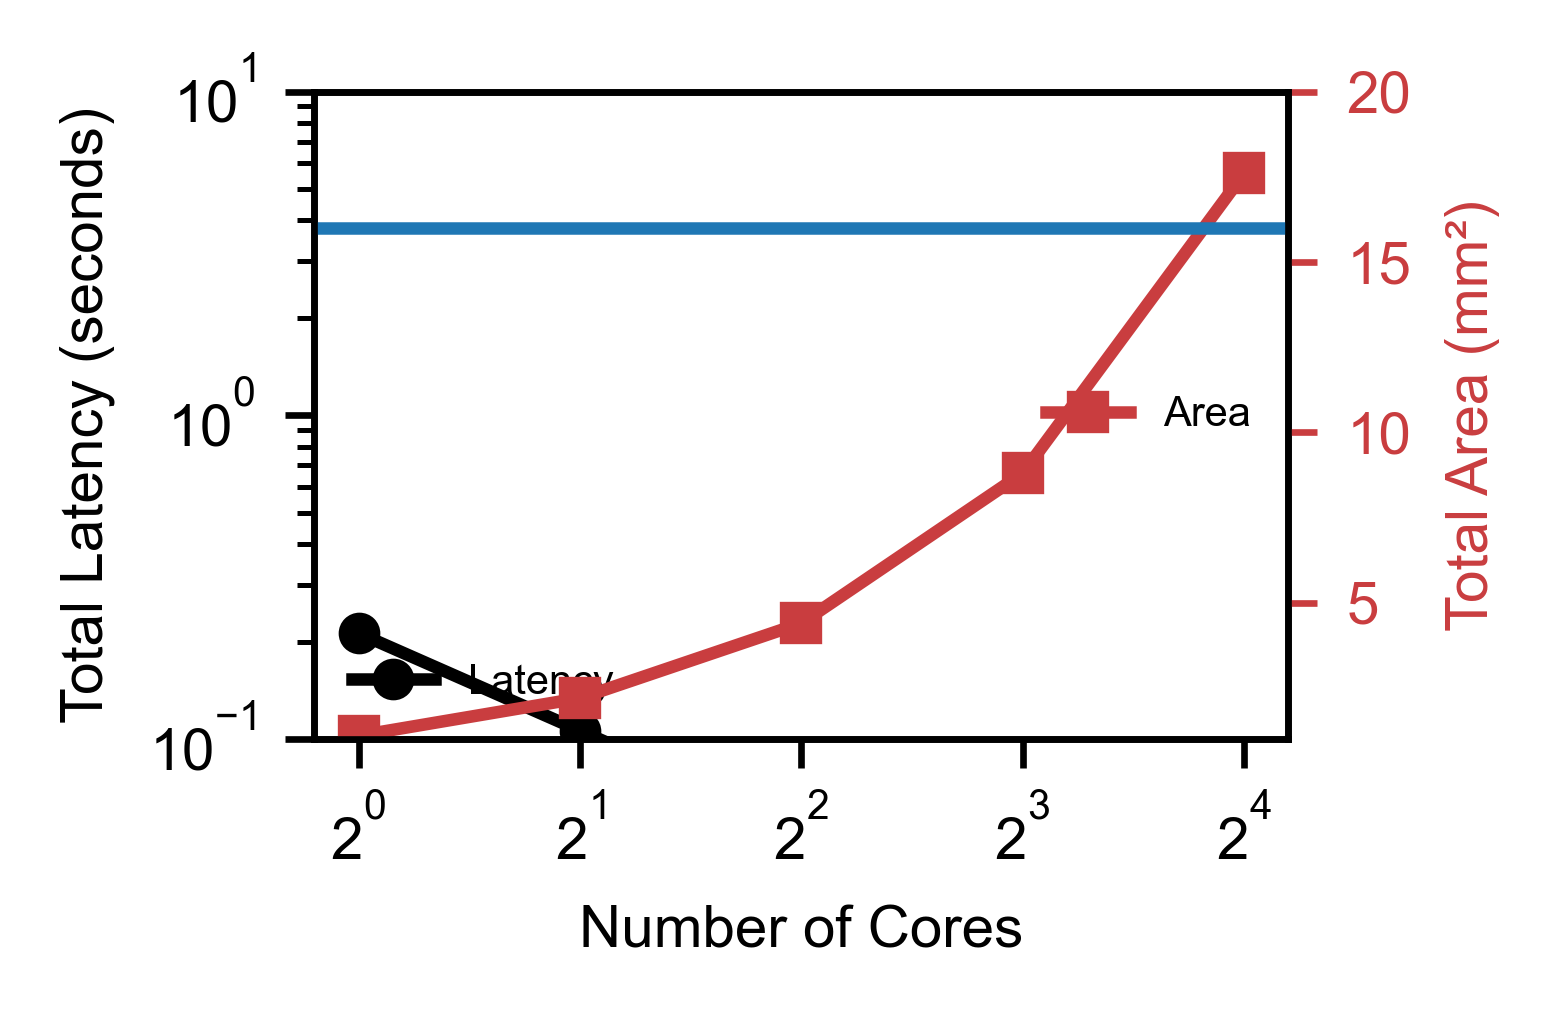

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

class CAMformerChip:
    def __init__(self, num_cores):
        self.base_latency = 3.4564e-05
        self.base_area = 2.2789
        self.num_cores = num_cores
        self.total_latency = 0

    def process_layer(self, m, n, k, dv):
        ops_per_core = np.ceil(m / self.num_cores)
        effective_latency = self.base_latency * ops_per_core
        self.total_latency += effective_latency
        return effective_latency

# Load and process data
df = pd.read_csv('/content/model_data.csv')
model_name = "bert-base-cola"
model_df = df[df['model'] == model_name]

cores_range = np.array([1, 2, 4, 8, 16,])
latencies = []
areas = []

for cores in cores_range:
    latency = process_model_with_cores(model_df, cores)
    area = 1.1 * cores
    latencies.append(latency)
    areas.append(area)

# Create figure with styled dimensions
fig, ax1 = plt.subplots(figsize=(3*0.9, 2*0.9), dpi=600)

# Plot latency on the left y-axis
ax1.plot(cores_range, latencies,
         marker='o',
         markersize=4,
         label='Latency',
         color='black')

# Set up left y-axis
ax1.set_xlabel('Number of Cores', fontsize=7)
ax1.set_ylabel('Total Latency (seconds)', fontsize=7, color='black')
ax1.tick_params(axis='x', labelsize=7)
ax1.tick_params(axis='y', labelsize=7, colors='black')
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')

# Create second y-axis for area
ax2 = ax1.twinx()
ax2.plot(cores_range, areas,
         marker='s',
         markersize=4,
         label='Area',
         color='#c93d3f')

# Set up right y-axis
ax2.set_ylabel('Total Area (mm²)', fontsize=7, color='#c93d3f')
ax2.tick_params(axis='y', labelsize=7, colors='#c93d3f')

# Set axis limits
ax1.set_ylim(1E-1, 1E1)
ax2.set_ylim(1, 20)
ax2.axhline(16)

# Set x-axis ticks
ax1.set_xticks(cores_range)

# Add legends
ax1.legend(loc='lower left', fontsize=5, frameon=False)
ax2.legend(loc='center right', fontsize=5, frameon=False)

# Adjust layout
plt.tight_layout()

# Print summary table
print("\nSummary Table:")
print("-" * 60)
print("Cores | Latency (s) | Area (mm²) | Latency Improvement")
print("-" * 60)
for i, cores in enumerate(cores_range):
    improvement = latencies[0] / latencies[i] if i > 0 else 1
    print(f"{cores:5d} | {latencies[i]:.6f} | {areas[i]:9.1f} | {improvement:18.2f}x")

plt.show()


Detailed Analysis for bert-base-squad-v2
----------------------------------------------------------------------------------------------------
Cores | Throughput (GOP/s) | Energy Eff. (GOP/J) | Area Eff. (GOP/s/mm²) | Latency (s) | Power (W) | Area (mm²)
----------------------------------------------------------------------------------------------------
1.0 |             0.79 |           7864.32 |                0.71 | 6.144000 | 0.000100 | 1.10
2.0 |             1.57 |           7864.32 |                0.71 | 3.072000 | 0.000200 | 2.20
4.0 |             3.15 |           7864.32 |                0.71 | 1.536000 | 0.000400 | 4.40
8.0 |             6.29 |           7864.32 |                0.71 | 0.768000 | 0.000800 | 8.80
16.0 |            12.58 |           7864.32 |                0.71 | 0.384000 | 0.001600 | 17.60
32.0 |            25.17 |           7864.32 |                0.71 | 0.192000 | 0.003200 | 35.20


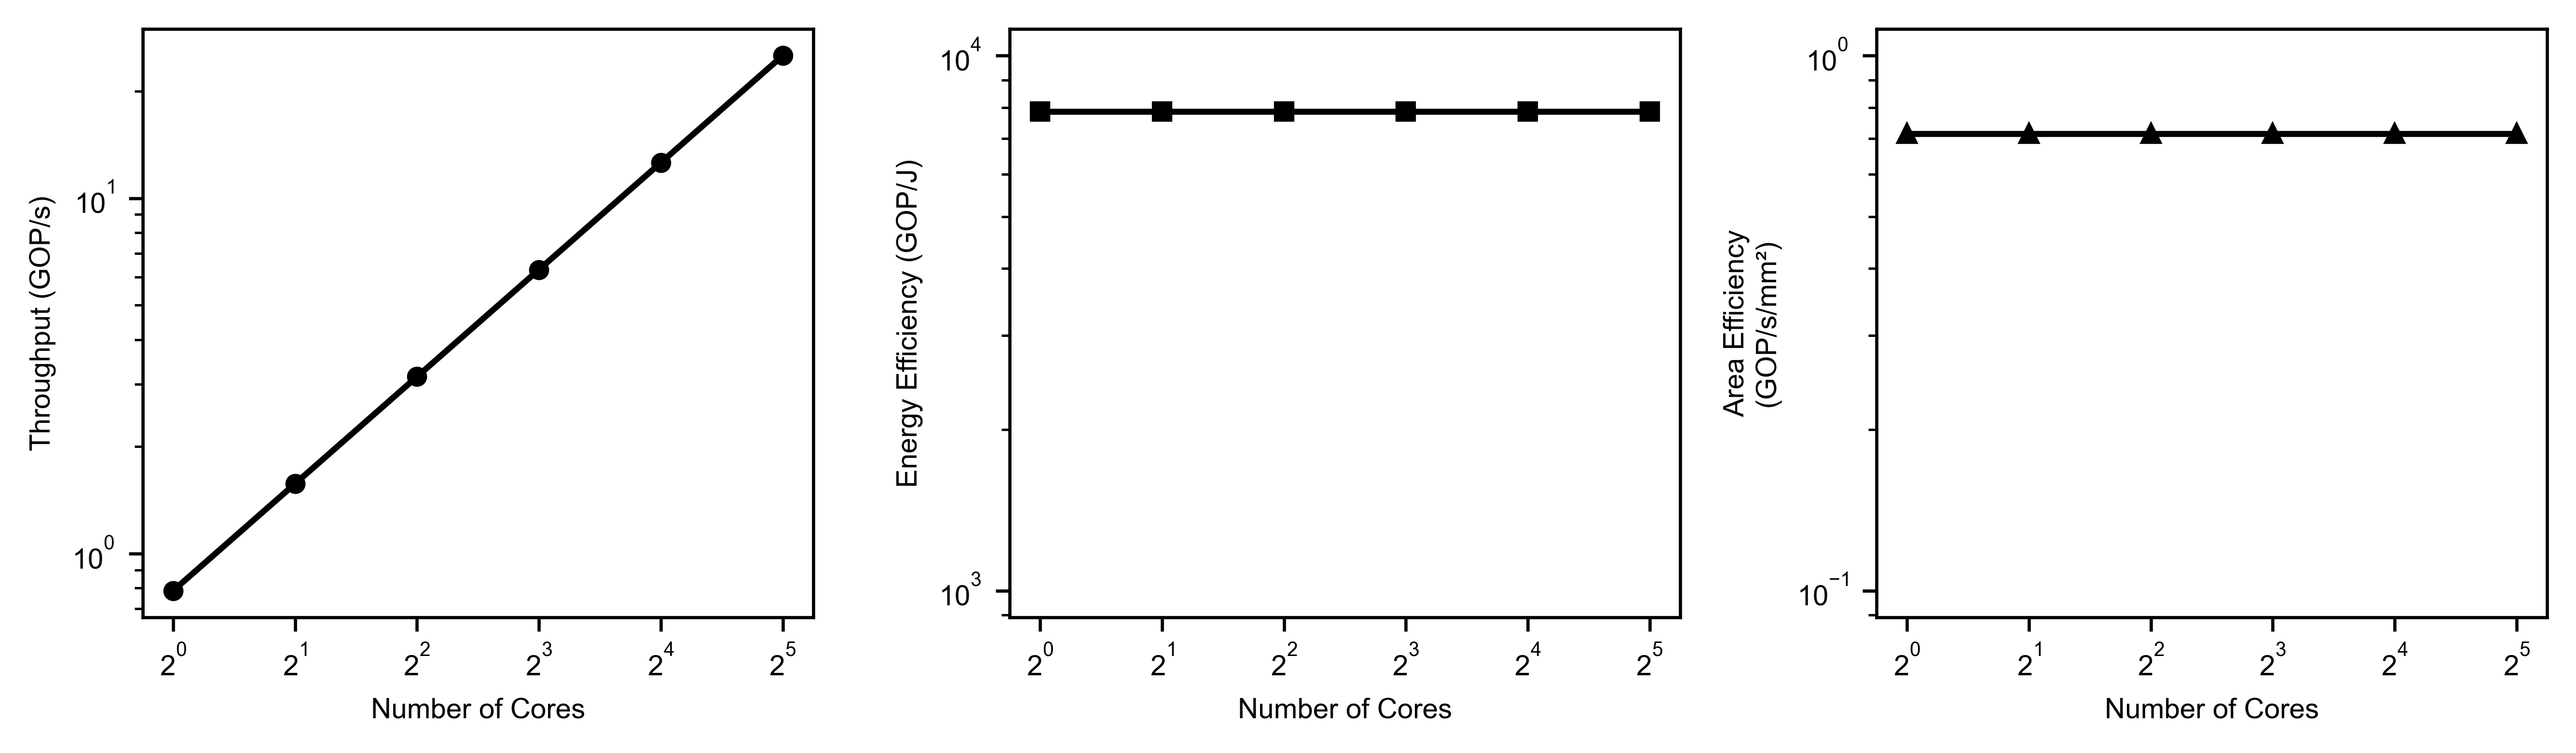

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class CAMformerChip:
    def __init__(self, num_cores):
        self.base_latency = 0.001  # seconds
        self.base_power = 0.0001   # Watts
        self.base_area = 1.1       # mm2
        self.num_cores = num_cores
        self.total_latency = 0
        self.total_power = self.base_power * num_cores
        self.total_area = self.base_area * num_cores

    def process_layer(self, m, n, k, dv):
        ops_per_core = np.ceil(m / self.num_cores)
        effective_latency = self.base_latency * ops_per_core
        self.total_latency += effective_latency
        return effective_latency

def compute_gops(m, n, k):
    """Compute number of operations for one layer
    In matrix multiplication: m×n×k needs 2×m×n×k operations (multiply and add)"""
    return 2 * m * n * k

def process_model_metrics(model_df, num_cores):
    chip = CAMformerChip(num_cores)

    # Calculate total operations across all layers
    total_ops = 0
    for _, row in model_df.iterrows():
        chip.process_layer(row['m'], row['n'], row['k'], row['dv'])
        total_ops += compute_gops(row['m'], row['n'], row['k'])

    # Convert operations to giga-operations (GOP)
    total_gops = total_ops / 1e9

    # Calculate metrics
    throughput = total_gops / chip.total_latency  # GOP/s
    energy_efficiency = throughput / chip.total_power  # GOP/J
    area_efficiency = throughput / chip.total_area  # GOP/s/mm2

    return {
        'cores': num_cores,
        'latency': chip.total_latency,
        'power': chip.total_power,
        'area': chip.total_area,
        'total_gops': total_gops,
        'throughput': throughput,
        'energy_efficiency': energy_efficiency,
        'area_efficiency': area_efficiency
    }

# Load and process data
df = pd.read_csv('/content/model_data.csv')
model_name = "bert-base-squad-v2"
model_df = df[df['model'] == model_name]

# Calculate metrics for different core counts
cores_range = [1, 2, 4, 8, 16, 32]
results = []

for cores in cores_range:
    metrics = process_model_metrics(model_df, cores)
    results.append(metrics)

# Convert results to DataFrame for easy printing
results_df = pd.DataFrame(results)

# Print detailed results
print(f"\nDetailed Analysis for {model_name}")
print("-" * 100)
print("Cores | Throughput (GOP/s) | Energy Eff. (GOP/J) | Area Eff. (GOP/s/mm²) | Latency (s) | Power (W) | Area (mm²)")
print("-" * 100)
for _, row in results_df.iterrows():
    print(f"{row['cores']} | {row['throughput']:16.2f} | {row['energy_efficiency']:17.2f} | {row['area_efficiency']:19.2f} | {row['latency']:.6f} | {row['power']:.6f} | {row['area']:.2f}")

# Create visualization
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 2.7), dpi=600)

# Plot Throughput
ax1.plot(cores_range, results_df['throughput'],
         marker='o', markersize=4, color='black')
ax1.set_xlabel('Number of Cores', fontsize=7)
ax1.set_ylabel('Throughput (GOP/s)', fontsize=7)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=7)
ax1.set_xticks(cores_range)

# Plot Energy Efficiency
ax2.plot(cores_range, results_df['energy_efficiency'],
         marker='s', markersize=4, color='black')
ax2.set_xlabel('Number of Cores', fontsize=7)
ax2.set_ylabel('Energy Efficiency (GOP/J)', fontsize=7)
ax2.set_xscale('log', base=2)
ax2.set_yscale('log')
ax2.tick_params(axis='both', labelsize=7)
ax2.set_xticks(cores_range)

# Plot Area Efficiency
ax3.plot(cores_range, results_df['area_efficiency'],
         marker='^', markersize=4, color='black')
ax3.set_xlabel('Number of Cores', fontsize=7)
ax3.set_ylabel('Area Efficiency\n(GOP/s/mm²)', fontsize=7)
ax3.set_xscale('log', base=2)
ax3.set_yscale('log')
ax3.tick_params(axis='both', labelsize=7)
ax3.set_xticks(cores_range)

plt.tight_layout()
plt.show()

In [ ]:
num = 128*2**10
print(num)
print(num*11/8/1024, "KB")

131072
176.0 KB


In [ ]:
num/32*3

12288.0

In [ ]:
num/32*3/32*3

1152.0

In [ ]:
num/32*3/32*3/32*3

108.0

In [ ]:
num/32*3/32*3/32*3/32*3

10.125

In [ ]:
num/32*3/32*3/32*3/32*3/81*30

3.75


Summary Table:
--------------------------------------------------------------------------------
Configuration | Latency (s) | Area (mm²) | Latency Improvement
--------------------------------------------------------------------------------
Cores:  1     | 0.141656 |      2.27 |               1.00x
Cores:  2     | 0.070828 |      4.54 |               2.00x
Cores:  4     | 0.035414 |      9.08 |               4.00x
Cores:  8     | 0.017707 |     18.16 |               8.00x
Cores: 16     | 0.008854 |     36.32 |              16.00x
Competition  | 0.033580 |     18.71 |               4.22x


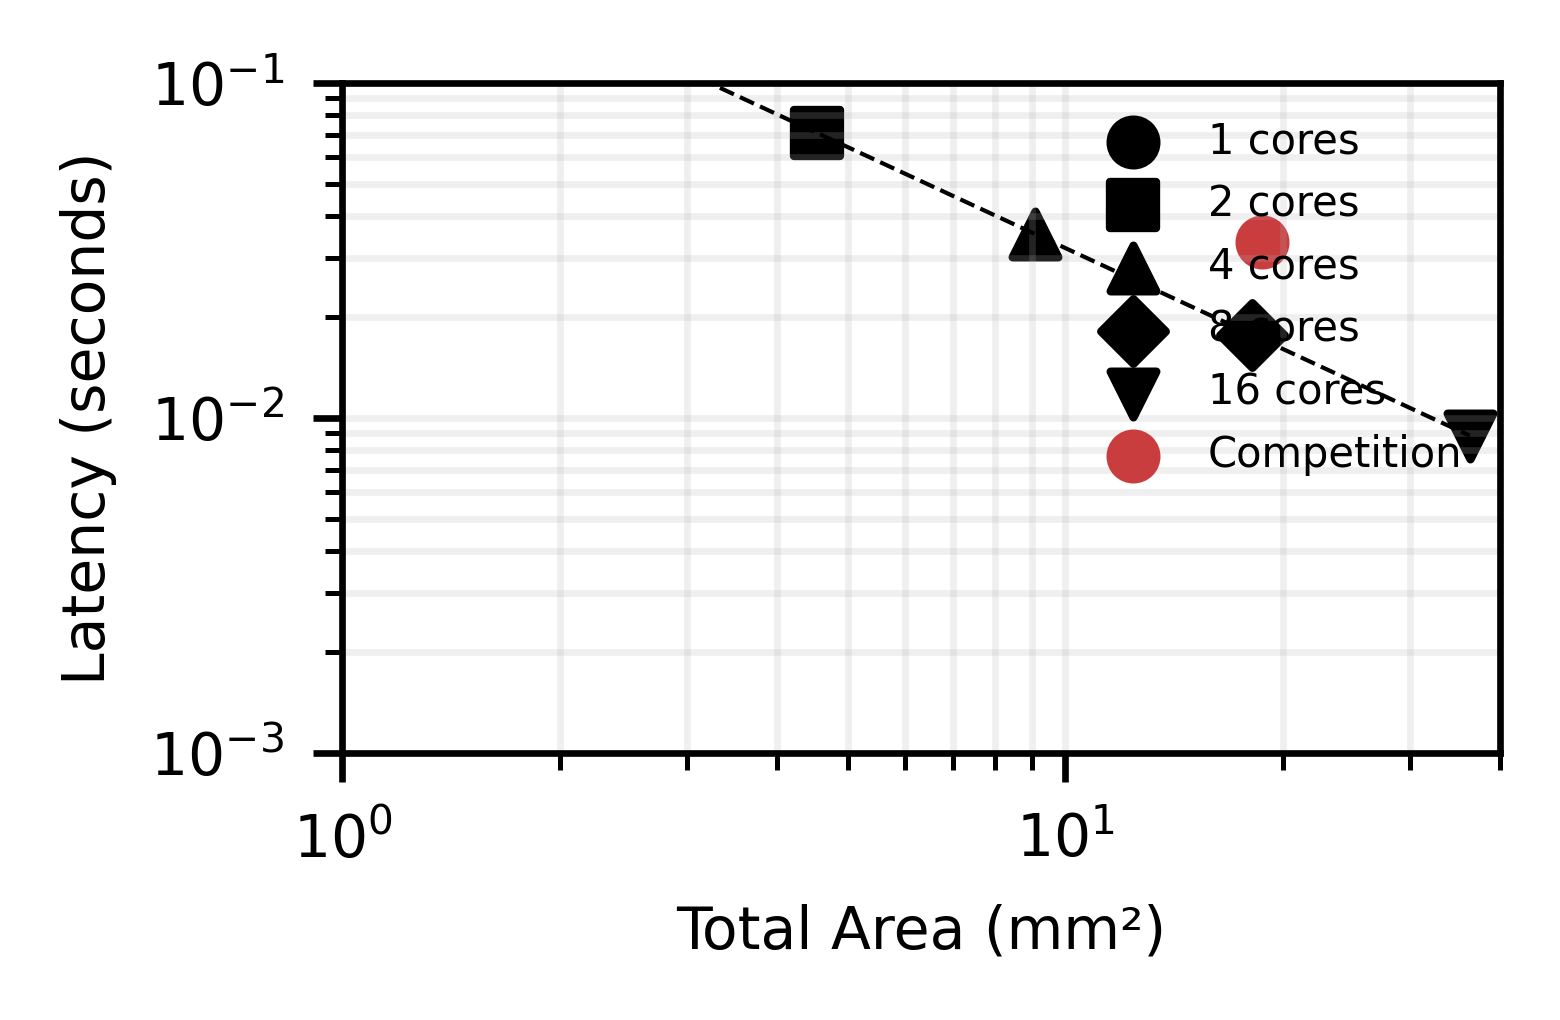

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

class CAMformerChip:
    def __init__(self, num_cores):
        self.base_latency = 5.764e-06
        self.base_area = 2.27
        self.num_cores = num_cores
        self.total_latency = 0

    def process_layer(self, m, n, k, dv):
        ops_per_core = np.ceil(m / self.num_cores)
        effective_latency = self.base_latency * ops_per_core
        self.total_latency += effective_latency
        return effective_latency

def process_model_with_cores(model_df, num_cores):
    chip = CAMformerChip(num_cores)
    for _, row in model_df.iterrows():
        chip.process_layer(row['m'], row['n'], row['k'], row['dv'])
    return chip.total_latency

# Load and process data
df = pd.read_csv('/content/model_data.csv')
model_name = "gpt2-medium-wikitext2"
model_df = df[df['model'] == model_name]

# Calculate metrics for different core counts
cores_range = np.array([1, 2, 4, 8, 16])
results = []

for cores in cores_range:
    latency = process_model_with_cores(model_df, cores)
    area = 2.27 * cores
    results.append({
        'cores': cores,
        'latency': latency,
        'area': area
    })

# Create figure
fig, ax = plt.subplots(figsize=(3*0.9, 2*0.9), dpi=600)

# Define markers for different core counts
markers = ['o', 's', '^', 'D', 'v']
colors = ['black'] * len(cores_range)

# Plot each point
for i, result in enumerate(results):
    ax.scatter(result['area'], result['latency'],
              marker=markers[i],
              s=30,
              color=colors[i],
              label=f'{result["cores"]} cores')

# Connect points with a line
areas = [r['area'] for r in results]
latencies = [r['latency'] for r in results]
ax.plot(areas, latencies, '--', color='black', linewidth=0.5)

# Add competition point
competition_area = 18.71
competition_latency = 0.033580
ax.scatter(competition_area, competition_latency,
          color='#c93d3f',  # Same red as before
          marker='o',
          s=30,
          label='Competition')

# Set up axes
ax.set_xlabel('Total Area (mm²)', fontsize=7)
ax.set_ylabel('Latency (seconds)', fontsize=7)
ax.tick_params(axis='both', labelsize=7)

# Set scales to log
ax.set_xscale('log')
ax.set_yscale('log')

# Set limits
ax.set_xlim(1, 40)
ax.set_ylim(1E-3, 1E-1)

# Add grid
ax.grid(True, which="both", ls="-", alpha=0.2)

# Add legend
ax.legend(fontsize=5, frameon=False, loc='upper right')

# Adjust layout
plt.tight_layout()

# Print summary table
print("\nSummary Table:")
print("-" * 80)
print("Configuration | Latency (s) | Area (mm²) | Latency Improvement")
print("-" * 80)
for result in results:
    improvement = results[0]['latency'] / result['latency'] if result['cores'] > 1 else 1
    print(f"Cores: {result['cores']:2d}     | {result['latency']:.6f} | {result['area']:9.2f} | {improvement:18.2f}x")
print(f"Competition  | {competition_latency:.6f} | {competition_area:9.2f} | {results[0]['latency']/competition_latency:18.2f}x")

plt.show()